# Bayesian Fitting with BUMPS

This notebook demonstrates the full high-level Bayesian MCMC API in
EasyReflectometry.

It covers:

- Building a reflectometry model with realistic bounds (critical for MCMC).
- Classical optimisation first (good starting point for Bayesian sampling).
- High-level DREAM MCMC sampling via
  ``MultiFitter.mcmc_sample()`` and ``PosteriorResults``.
- Posterior inspection: summary table, marginal distributions, corner plot,
  trace plot, credible intervals, Gelman-Rubin R-hat.
- Posterior-predictive checks: reflectivity and SLD profile with 95 %
  credible bands.

All posterior plots are rendered as **interactive Plotly figures**, the
same ones shown by the EasyReflectometryApp Bayesian Posterior tab.

**Note**: Requires ``arviz`` and ``plotly`` (install via
``pip install easyreflectometry[dev]``).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pooch
from easyscience.fitting import AvailableMinimizers

from easyreflectometry.analysis.bayesian import PosteriorResults
from easyreflectometry.analysis.bayesian import plot_corner
from easyreflectometry.analysis.bayesian import plot_trace
from easyreflectometry.analysis.bayesian import posterior_predictive_reflectivity
from easyreflectometry.analysis.bayesian import posterior_predictive_sld_profile
from easyreflectometry.calculators import CalculatorFactory
from easyreflectometry.data.measurement import load
from easyreflectometry.fitting import MultiFitter
from easyreflectometry.model import Model
from easyreflectometry.model import PercentageFwhm
from easyreflectometry.sample import Layer
from easyreflectometry.sample import Material
from easyreflectometry.sample import Multilayer
from easyreflectometry.sample import Sample

warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


Data loaded with keys: ['data', 'coords', 'attrs']


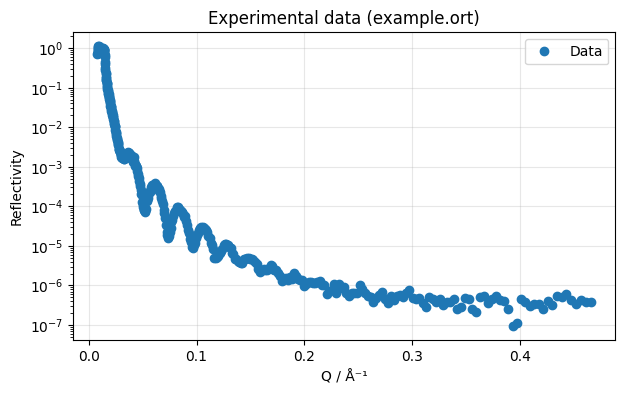

In [2]:
# ---- Load experimental data -------------------------------------------------
# Fetch the .ort test data from the easyscience/reflectometry data repository.
data_path = pooch.retrieve(
    url='https://raw.githubusercontent.com/easyscience/reflectometry/master/data/example.ort',
    known_hash='82d0c95c069092279a799a8131ad3710335f601d9f1080754b387f42e407dfab',
)
data = load(data_path)
print('Data loaded with keys:', list(data.keys()))

# Quick look at the data
qz = data['coords']['Qz_0'].values
r_data = data['data']['R_0'].values

plt.figure(figsize=(7, 4))
plt.semilogy(qz, r_data, 'o', label='Data')
plt.xlabel('Q / Å⁻¹')
plt.ylabel('Reflectivity')
plt.title('Experimental data (example.ort)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# ---- Create a monolayer model (Si / Film / D₂O) ----------------------------
si = Material(sld=2.07, isld=0.0, name='Si')
film = Material(sld=2.0, isld=0.0, name='Film')
d2o = Material(sld=6.36, isld=0.0, name='D2O')

si_layer = Layer(material=si, thickness=0.0, roughness=3.0, name='Si')
film_layer = Layer(material=film, thickness=250.0, roughness=3.0, name='Film')
d2o_layer = Layer(material=d2o, thickness=0.0, roughness=3.0, name='D2O')

sample = Sample(
    Multilayer(si_layer),
    Multilayer(film_layer),
    Multilayer(d2o_layer),
    name='Monolayer Sample',
)

resolution = PercentageFwhm(0.02)
model = Model(
    sample=sample,
    scale=1.0,
    background=1e-6,
    resolution_function=resolution,
    name='Monolayer Model',
)

# ---- Make key parameters free with realistic bounds (essential for MCMC) -----
film_layer.thickness.fixed = False
film_layer.thickness.bounds = (100, 400)

film.sld.fixed = False
film.sld.bounds = (0.5, 4.0)

model.scale.fixed = False
model.scale.bounds = (0.8, 1.2)

model.background.fixed = False
model.background.bounds = (1e-7, 1e-5)

print('Model created with the following free parameters:')
for p in model.get_parameters():
    if not p.fixed:
        print(f'  {p.name}: value={p.value}, bounds={p.bounds}')

Model created with the following free parameters:
  background: value=1e-06, bounds=(1e-07, 1e-05)
  sld: value=2.0, bounds=(0.5, 4.0)
  thickness: value=250.0, bounds=(100, 400)
  scale: value=1.0, bounds=(0.8, 1.2)


In [4]:
# ---- Set up the calculator and fitter ---------------------------------------
interface = CalculatorFactory()
interface.switch('refnx')  # or 'refl1d'
model.interface = interface

fitter = MultiFitter(model)
# Use the BUMPS backend — DREAM sampling is only available through BUMPS.
fitter.switch_minimizer(AvailableMinimizers.Bumps)

print('Fitter ready with minimizer:', fitter.easy_science_multi_fitter.minimizer.name)

Fitter ready with minimizer: Bumps


Classical fit successful: True
Reduced χ² ≈ 73.7860402885366


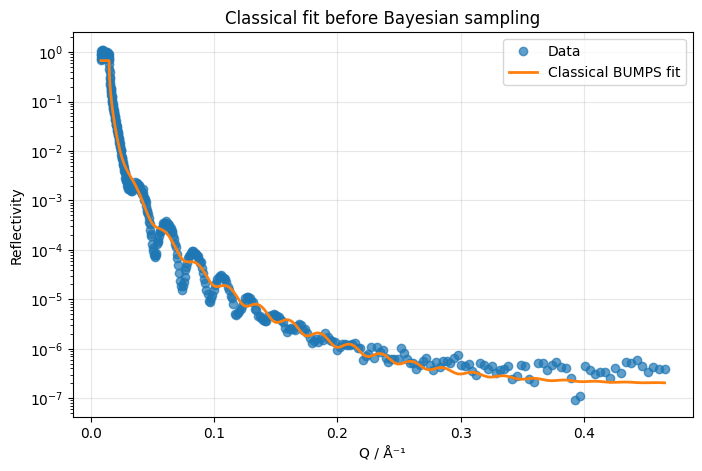

In [5]:
# ---- Classical fit first ----------------------------------------------------
# A classical optimisation gives a good starting point and a sanity check
# before launching the (much more expensive) MCMC sampler.

analysed = fitter.fit(data)

print('Classical fit successful:', analysed.get('success', 'N/A'))
print('Reduced χ² ≈', analysed.get('reduced_chi', 'N/A'))

# Plot the fit
r_model = analysed['R_0_model'].values

plt.figure(figsize=(8, 5))
plt.semilogy(qz, r_data, 'o', label='Data', alpha=0.7)
plt.semilogy(qz, r_model, '-', label='Classical BUMPS fit', linewidth=2)
plt.xlabel('Q / Å⁻¹')
plt.ylabel('Reflectivity')
plt.title('Classical fit before Bayesian sampling')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# ---- Bayesian MCMC sampling -------------------------------------------------
# ``MultiFitter.mcmc_sample()`` delegates to the BUMPS DREAM sampler.
# All keyword arguments are forwarded with user-friendly names:
#   ``samples``   ← total retained samples
#   ``burn``      ← burn‑in steps
#   ``thin``      ← thinning interval
#   ``population``← BUMPS‑native ``pop`` for advanced users

posterior_dict = fitter.mcmc_sample(
    data,
    samples=2000,  # Short for demo; use 20 k+ in production
    burn=500,
    thin=10,
)

print('DREAM sampling complete.')
print(f'  Posterior shape  : {posterior_dict["draws"].shape}')
print(f'  Parameters        : {posterior_dict["param_names"]}')

DREAM sampling complete.
  Posterior shape  : (120, 4)
  Parameters        : ['Layer_1_ThicknessParameter_0', 'Material_1_SldParameter_0', 'Parameter_0', 'Parameter_1']


In [7]:
# ---- Wrap in PosteriorResults -----------------------------------------------
# ``PosteriorResults`` gives you a convenient object with built-in analysis
# methods.  You can also use the raw ``dict`` with the standalone functions
# — both styles are shown below.

posterior = PosteriorResults(
    draws=posterior_dict['draws'],
    param_names=posterior_dict['param_names'],
    logp=posterior_dict.get('logp'),
    sampler_state=posterior_dict.get('state'),
)

print(posterior)

PosteriorResults(n_samples=120, n_params=4, param_names=['Layer_1_ThicknessParameter_0', 'Material_1_SldParameter_0', 'Parameter_0', 'Parameter_1'])


In [8]:
# ---- Posterior summary table ------------------------------------------------
# ``.summary()`` prints mean, standard deviation and 95 % HDI for each parameter.

print(posterior.summary())

parameter                            mean         sd      q2.5%     q97.5%
Layer_1_ThicknessParameter_0     252.6802     0.2191   252.2955   253.1192
Material_1_SldParameter_0          1.5483     0.0088     1.5306     1.5649
Parameter_0                        0.6736     0.0021     0.6694     0.6775
Parameter_1                        0.0000     0.0000     0.0000     0.0000


## Interactive posterior plots

The next three cells render the same Plotly figures that are shown on the
Bayesian Posterior tab of the EasyReflectometryApp:

* **Marginals** — per-parameter distribution: histogram + smooth KDE marginal,
  shaded 95% credible interval, and median / best-sample lines
  (`plot_distribution` or `posterior.distribution()`)
* **Corner plot** — pairwise marginals + 2-D contours + scatter (`plot_corner`)
* **Traces** — per-chain trace + marginal histogram (`plot_trace`)

The standalone helpers are called with ``return_figure=True`` so they return a
Plotly ``Figure`` that we render in the notebook with ``fig.show()``; the
``PosteriorResults`` methods return the figure directly.

In [9]:
# ---- Marginal posterior distributions ---------------------------------------
# One panel per free parameter, each overlaying the posterior histogram, a
# smooth Gaussian-KDE marginal, the shaded 95% credible interval, and the
# median / best-sample reference lines.  Mirrors the "Marginals" sub-tab in
# the EasyReflectometryApp.

# The PosteriorResults method passes ``logp`` through automatically so the
# best posterior sample (MAP) line is drawn:
fig = posterior.distribution()
fig.show()

# Standalone equivalent (pass ``logp`` to get the best-sample line):
# fig = plot_distribution(
#     posterior.draws,
#     posterior.param_names,
#     logp=posterior.logp,
#     return_figure=True,
# )
# fig.show()

In [10]:
# ---- Corner plot ------------------------------------------------------------
# Pairwise correlations: marginal density on the diagonal, scatter samples
# and 2-D contours on the lower triangle.  Mirrors the "Corner Plot" sub-tab.

fig = plot_corner(posterior.draws, posterior.param_names)
fig.show()

In [11]:
# ---- Trace plot -------------------------------------------------------------
# Per-chain trace (left column) and marginal histogram (right column).
# Mirrors the "Traces" sub-tab in the EasyReflectometryApp.

fig = plot_trace(posterior.draws, posterior.param_names, return_figure=True)
fig.show()

In [12]:
# ---- Credible intervals -----------------------------------------------------
# Equal-tailed 95 % credible intervals for each parameter.

ci_95 = posterior.credible_interval(alpha=0.95)
print('95 % credible intervals:')
for name, (lo, hi) in ci_95.items():
    print(f'  {name:<30s}  [{lo:.4f}, {hi:.4f}]')

# You can request narrower intervals too:
ci_50 = posterior.credible_interval(alpha=0.50)
print('\n50 % credible intervals:')
for name, (lo, hi) in ci_50.items():
    print(f'  {name:<30s}  [{lo:.4f}, {hi:.4f}]')

# Standalone equivalent:
# ci = credible_intervals(posterior.draws, posterior.param_names, alpha=0.95)

95 % credible intervals:
  Layer_1_ThicknessParameter_0    [252.2955, 253.1192]
  Material_1_SldParameter_0       [1.5306, 1.5649]
  Parameter_0                     [0.6694, 0.6775]
  Parameter_1                     [0.0000, 0.0000]

50 % credible intervals:
  Layer_1_ThicknessParameter_0    [252.5296, 252.8121]
  Material_1_SldParameter_0       [1.5415, 1.5546]
  Parameter_0                     [0.6722, 0.6751]
  Parameter_1                     [0.0000, 0.0000]


In [13]:
# ---- Pairwise focus: thickness vs SLD ---------------------------------------
# A 2-parameter corner plot zooms in on the joint posterior for a specific
# pair.  This is the same view the EasyReflectometryApp's "2D Heatmap"
# sub-tab uses to inspect parameter degeneracies.


params_of_interest = ['Layer_1_ThicknessParameter_0', 'Material_1_SldParameter_0']
idx = [posterior.param_names.index(p) for p in params_of_interest]
subset_draws = np.asarray(posterior.draws)[:, idx]

fig = plot_corner(subset_draws, params_of_interest)
fig.show()

In [14]:
# ---- Gelman-Rubin R‑hat convergence diagnostic ------------------------------
# Requires ``arviz`` and at least 2 chains.  Values close to 1.0 indicate
# good convergence.

try:
    rhat = posterior.gelman_rubin()
    print('Gelman-Rubin R‑hat:')
    for name, r in rhat.items():
        flag = ' ✓' if r < 1.1 else ' ⚠'
        print(f'  {name:<30s}  R̂ = {r:.3f}{flag}')
except ValueError:
    print(
        'Skipped: Gelman-Rubin R‑hat requires at least 2 chains. '
        'Run with multiple DREAM populations to obtain multi-chain draws.'
    )

Skipped: Gelman-Rubin R‑hat requires at least 2 chains. Run with multiple DREAM populations to obtain multi-chain draws.


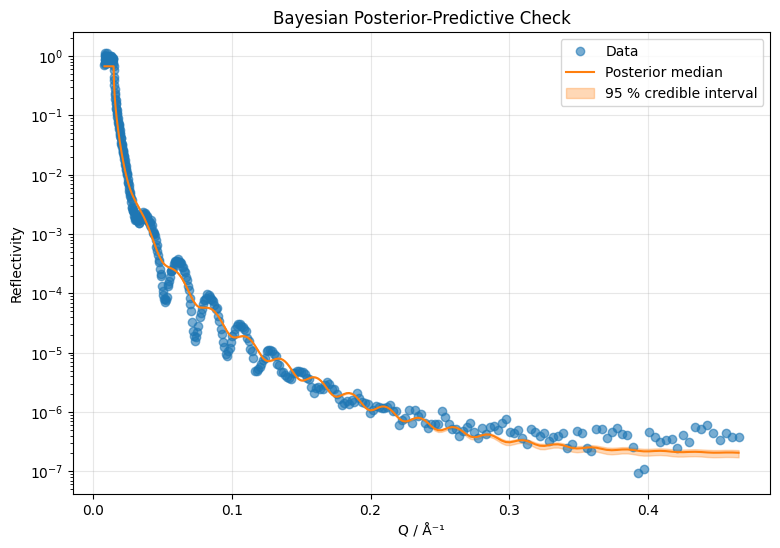

The 95 % credible interval captures parameter uncertainty propagated through the model.


In [15]:
# ---- Posterior-predictive reflectivity --------------------------------------
# Propagate parameter uncertainty through the model to obtain median
# reflectivity and 95 % credible band.

r_median, r_lower, r_upper = posterior_predictive_reflectivity(
    posterior.draws,
    posterior.param_names,
    model,
    qz,
    n_samples=200,
)

plt.figure(figsize=(9, 6))
plt.semilogy(qz, r_data, 'o', label='Data', alpha=0.6)
plt.semilogy(qz, r_median, '-', color='tab:orange', label='Posterior median')
plt.fill_between(
    qz,
    r_lower,
    r_upper,
    color='tab:orange',
    alpha=0.3,
    label='95 % credible interval',
)
plt.xlabel('Q / Å⁻¹')
plt.ylabel('Reflectivity')
plt.title('Bayesian Posterior-Predictive Check')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('The 95 % credible interval captures parameter uncertainty propagated through the model.')

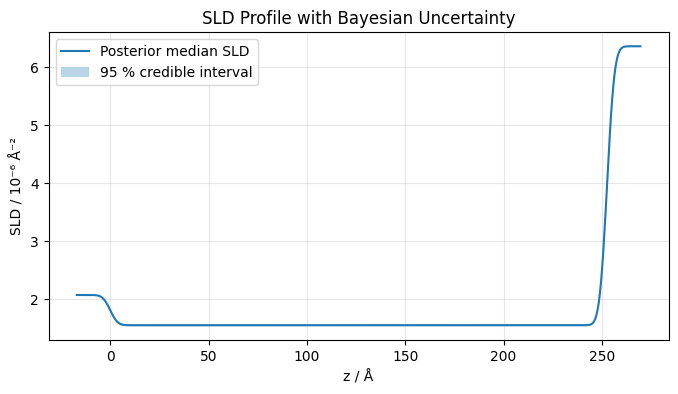

In [16]:
# ---- Posterior-predictive SLD profile ---------------------------------------
# The same idea applied to the scattering-length-density profile.

z, sld_median, sld_lower, sld_upper = posterior_predictive_sld_profile(
    posterior.draws,
    posterior.param_names,
    model,
    n_samples=200,
)

plt.figure(figsize=(8, 4))
plt.plot(z, sld_median, label='Posterior median SLD')
plt.fill_between(
    z,
    sld_lower,
    sld_upper,
    alpha=0.3,
    label='95 % credible interval',
)
plt.xlabel('z / Å')
plt.ylabel('SLD / 10⁻⁶ Å⁻²')
plt.title('SLD Profile with Bayesian Uncertainty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# ---- Summary ----------------------------------------------------------------
print('―' * 60)
print('Bayesian analysis complete!')
print('―' * 60)
print()
print('API surface demonstrated:')
print('  MultiFitter.mcmc_sample(data, samples=, burn=, thin=)')
print('  PosteriorResults(draws, param_names, logp=, sampler_state=)')
print('    .summary()                — formatted parameter table')
print('    .distribution()           — per-parameter marginal Plotly figure')
print('    .corner()                 — pairwise correlation Plotly figure')
print('    .trace()                  — MCMC chain trace plot')
print('    .credible_interval(alpha) — equal-tailed credible intervals')
print('    .gelman_rubin()           — R̂ convergence diagnostic')
print()
print('  Standalone functions (work on raw dict; the plot helpers return')
print('  the same interactive Plotly figures as the App):')
print('    posterior_summary(draws, names)')
print('    plot_distribution(draws, names, logp=, return_figure=True)')
print('    plot_corner(draws, names)')
print('    plot_trace(draws, names, return_figure=True)')
print('    credible_intervals(draws, names, alpha)')
print('    posterior_predictive_reflectivity(draws, names, model, q, n)')
print('    posterior_predictive_sld_profile(draws, names, model, n)')
print()
print('The high-level API provides clean, safe access to BUMPS DREAM sampling.')

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Bayesian analysis complete!
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

API surface demonstrated:
  MultiFitter.mcmc_sample(data, samples=, burn=, thin=)
  PosteriorResults(draws, param_names, logp=, sampler_state=)
    .summary()                — formatted parameter table
    .distribution()           — per-parameter marginal Plotly figure
    .corner()                 — pairwise correlation Plotly figure
    .trace()                  — MCMC chain trace plot
    .credible_interval(alpha) — equal-tailed credible intervals
    .gelman_rubin()           — R̂ convergence diagnostic

  Standalone functions (work on raw dict; the plot helpers return
  the same interactive Plotly figures as the App):
    posterior_summary(draws, names)
    plot_distribution(draws, names, logp=, return_figure=True)
    plot_corner(draws, names)
    plot_trace(draws, names, return_figure=True)
    credible_intervals(draws, names, al